## Лабораторная работа №8. Конечно-разностные схемы.


### Гиперболические задачи

$$
\frac{\partial^2 u}{\partial t^2} = a^2 \frac{\partial^2 u}{\partial x^2}
$$

Условие устойчивости Куранта (CFL)
   $$\sigma = \frac{a \tau}{h} \leq 1$$

### Параболический тип

Уравнение теплопроводности:

$$
\frac{\partial u}{\partial t} = a^2 \frac{\partial^2 u}{\partial x^2}
$$

Решаются приемущественно неявными схемами:

$$
\frac{u_j^{n+1} - u_j^n}{\Delta t} = a^2 \frac{u_{j+1}^{n+1} - 2u_j^{n+1} + u_{j-1}^{n+1}}{\Delta x^2}
$$

Где на каждом шаге нужно решать систему линейных уравнений (прогонка в 1D, итерации в 2D/3D).

**Схема Лакса–Вендорфа**
$$
u_j^{n+1} = u_j^n - \frac{a\tau}{2h} \left( u_{j+1}^n - u_{j-1}^n \right) + \frac{a^2\tau^2}{2h^2} \left( u_{j+1}^n - 2u_j^n + u_{j-1}^n \right)
$$

**Схема Куранта–Изаксона–Риса (Courant–Isaacson–Rees)**
$$
u_j^{n+1} = u_j^n - \frac{\tau}{2h} \left[ a \left( u_{j+1}^n - u_{j-1}^n \right) - |a| \left( u_{j+1}^n - 2u_j^n + u_{j-1}^n \right) \right]
$$


**Схема Уорминга–Кутлера–Ломакса (Warming–Kutler–Lomax)**
$$
u_j^{n+1} = u_j^n - \frac{a\tau}{h} \left( u_j^n - u_{j-1}^n \right) - \frac{a\tau}{2h} \left( 1 - \frac{a\tau}{h} \right) \left( u_j^n - 2u_{j-1}^n + u_{j-2}^n \right)
$$

#### Задача 14

Уравнение Бюргерса, описывающее перенос и диффузию загрязнений в воздухе:

$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = \mu \frac{\partial^2 u}{\partial x^2}$$

$$u(0, t) = U, u(L, t) = 0, u(x, 0) = 0$$

$$x \in [0, L], t \in [0, T]$$
где $u$ - концентрация некоторого вещества, $\mu$ - коэффициент диффузии, $c$ - постоянная скорость потока.

Точное решение при $u(x, 0) = sin(k x)$:
$$u(x, t) = exp(- k^2 \mu t) sin (k(x - ct))$$

In [77]:
import numpy as np

from comp_math.finite_difference.burgers.burgers_problem import BurgersProblem
from comp_math.finite_difference.burgers.burgers_solver import BurgersSolver

from comp_math.finite_difference.imagine_solution import plot_heatmap

In [78]:
def U0t(t: float) -> float:
    return 0.0

def ULt(t: float) -> float:
    return 0.0

k1 = np.pi * 2.0
k2 = 1.0

def Ux0(x: float) -> float:
    return k2 * np.sin(x * k1)

T = 0.3
L = 1.0
c = 1.0
mu = 1.0

tau = 0.001
h = 0.01

problem14 = BurgersProblem(U0t=U0t, ULt=ULt, Ux0=Ux0, T=T, L=L, c=c, mu=mu)

burgersSolver = BurgersSolver(problem14)

u = burgersSolver.solve(tau, h)

In [79]:
def get_exact_u1():
    t_num = int(T / tau)
    x_num = int(L / h)
    exact_u1 = np.zeros(shape=(t_num, x_num))
    for n in range(t_num):
        for j in range(x_num):
            t = n * tau
            x = j * h
            exact_u1[n][j] = k2 * np.exp(- k1 ** 2 * mu * t) * np.sin(k1 * (x - c * t))
    return exact_u1

exact_u1 = get_exact_u1()

def allclose_2d(a, b, eps=1e-2):
    return np.allclose(a, b, rtol=0, atol=eps)

print("Checking result: ", allclose_2d(exact_u1, u))

print("Shapes:", exact_u1.shape, u.shape)
print("Max diff:", np.max(np.abs(exact_u1 - u)))

Checking result:  False
Shapes: (300, 100) (300, 100)
Max diff: 0.08652738076424023


<Axes: title={'center': 'Burgers Exact'}, xlabel='x', ylabel='t'>

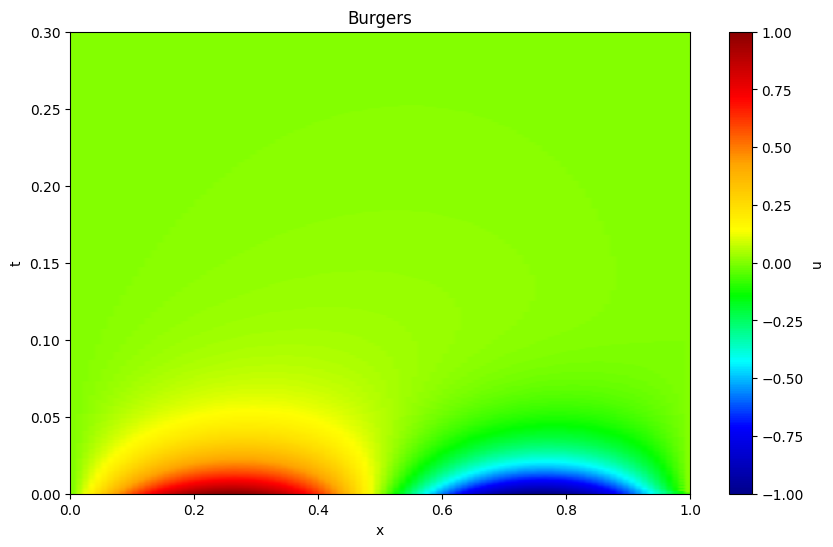

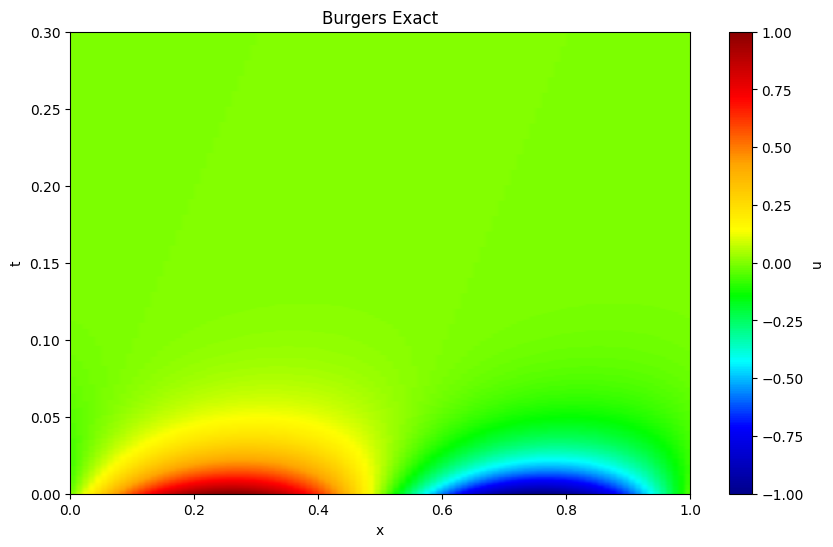

In [80]:
x = np.arange(0, L + h, h)
t = np.arange(0, T + tau, tau)

plot_heatmap(u, x, t, title="Burgers", cmap="thermal")
plot_heatmap(exact_u1, x, t, title="Burgers Exact", cmap="thermal")
